In [16]:
from sklearn.datasets import load_iris
import seaborn as sns
from sklearn.cluster import KMeans
import pandas as pd

In [17]:
iris = load_iris()

In [18]:
X = iris.data

y = iris.target  # we dont need it 

In [19]:
X.shape

(150, 4)

<Axes: >

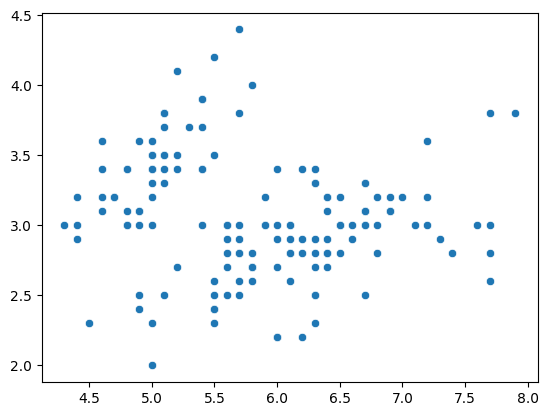

In [20]:
# Visualize

sns.scatterplot(x=X[:,0],y=X[:,1])  # we have 4 features but we cant visualize for 4 features beacuse it will became 4d so lets visulaize for any of two features 

In [21]:
# scalling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [26]:
# elbow method to find k ( now we know k should be 3)
wcss = []

for k in range (1,11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit_predict(X_scaled)
    wcss.append(kmeans.inertia_)

from kneed import KneeLocator
print("best k value will be : ",KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing").elbow)

best k value will be :  3


<Axes: >

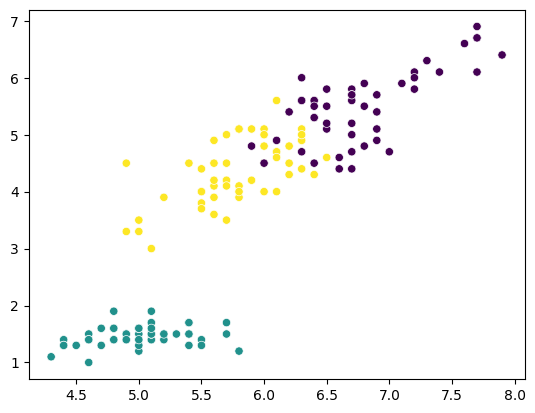

In [28]:
# Kmeans

kmeans = KMeans(n_clusters=3)
labels = kmeans.fit_predict(X_scaled)

sns.scatterplot(x=X[:,0],y=X[:,2],c=labels)

In [30]:
# optional- dimensionality reduction using PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2) # merge all fetures to 2 we do dimensioanlity reduction when we have too much features and it is hard to visualize and form clusters
pca_data = pca.fit_transform(X_scaled)

In [31]:
wcss = []

for k in range (1,11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit_predict(pca_data)
    wcss.append(kmeans.inertia_)

from kneed import KneeLocator
print("best k value will be : ",KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing").elbow)

best k value will be :  3


<Axes: >

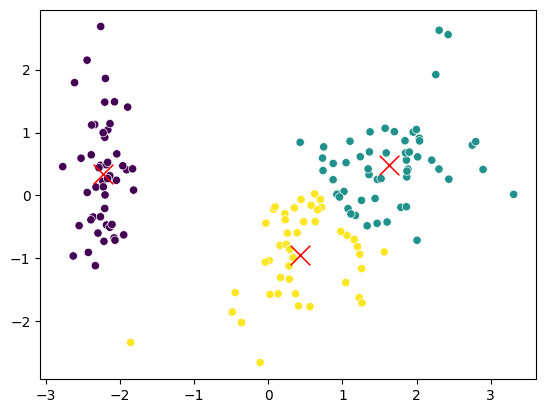

In [36]:
# Kmeans

kmeans = KMeans(n_clusters=3)
labels = kmeans.fit_predict(pca_data)

sns.scatterplot(x=pca_data[:,0],y=pca_data[:,1],c=labels)
sns.scatterplot(x=kmeans.cluster_centers_[:,0],y=kmeans.cluster_centers_[:,1],marker = 'x',c='red',s=200)